In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib

In [3]:
FOLD = 0

with open(f"../data/splits/fold_{FOLD}/train.txt") as f:
    train_cases = f.read().splitlines()

with open(f"../data/splits/fold_{FOLD}/val.txt") as f:
    val_cases = f.read().splitlines()

In [4]:
case = val_cases[8]  
print("Testing case:", case)

image = nib.load(f"../data/processed/imagesTr/{case}.nii.gz").get_fdata()
label = nib.load(f"../data/processed/labelsTr/{case}.nii.gz").get_fdata()


Testing case: case_02


In [5]:
z = image.shape[0] // 2

ct_slice = image[z]
gt_slice = label[z]

(np.float64(-0.5), np.float64(162.5), np.float64(162.5), np.float64(-0.5))

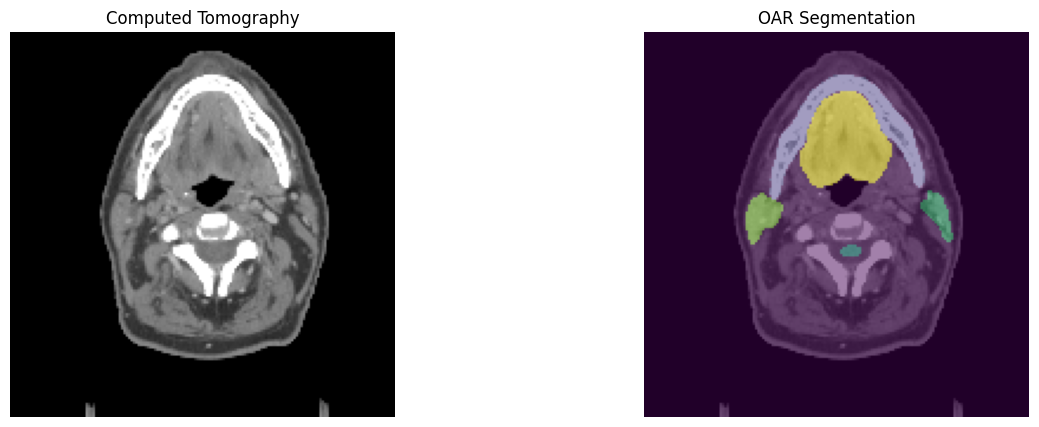

In [11]:
def zoom_center(img, zoom_factor=0.5):
    h, w = img.shape[:2]
    
    # New cropped size
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    
    # Center crop coordinates
    start_h = (h - new_h) // 2
    start_w = (w - new_w) // 2
    
    return img[start_h:start_h+new_h, start_w:start_w+new_w]

# Apply zoom
ct_zoom = zoom_center(ct_slice, 0.35)
gt_zoom = zoom_center(gt_slice, 0.35)

plt.figure(figsize=(15,5))

# CT
plt.subplot(1,2,1)
plt.imshow(ct_zoom, cmap='gray')
plt.title("Computed Tomography")
plt.axis("off")

# Ground Truth
plt.subplot(1,2,2)
plt.imshow(ct_zoom, cmap='gray')
plt.imshow(gt_zoom, alpha=0.5)
plt.title("OAR Segmentation")
plt.axis("off")
